# SAP MM — Procure-to-Pay (P2P) Simulation
**Company:** NexaManufacture India Pvt. Ltd. | **Module:** SAP MM

| Step | Document | T-Code |
|------|----------|--------|
| 1 | Purchase Requisition | ME51N |
| 2 | RFQ + Vendor Quote + Price Comparison | ME41 / ME47 / ME49 |
| 3 | Purchase Order | ME21N |
| 4 | Goods Receipt | MIGO |
| 5 | Invoice Verification (3-Way Match) | MIRO |
| 6 | Vendor Payment | F-53 |

In [ ]:
# SETUP
!pip install tabulate --quiet
import datetime
from tabulate import tabulate

vendors = {
    'V-2001': {'name': 'Bharat Steel Components Ltd.', 'terms': 'Net 45 Days', 'method': 'NEFT', 'liab': 0},
    'V-2002': {'name': 'PrimeTech Supplies Pvt. Ltd.', 'terms': 'Net 30 Days', 'method': 'RTGS', 'liab': 0},
}
mat = {'id': 'ROH-5001', 'desc': 'Cold Rolled Steel Sheets', 'uom': 'KG',
       'price': 85.00, 'tax': 0.18, 'stock': 200, 'reorder': 500}

ctr = {'PR':10010000,'RFQ':60010000,'PO':45000000,'GR':50000000,'IR':51000000,'PAY':15000000}
def nxt(t): ctr[t]+=1; return f'{t}-{ctr[t]}'
docs = {}

print('Setup complete. Vendors and material master loaded.')
print(f'Material : {mat["id"]} — {mat["desc"]} | Stock: {mat["stock"]} {mat["uom"]}')

Setup complete. Vendors and material master loaded.
Material : ROH-5001 — Cold Rolled Steel Sheets | Stock: 200 KG


In [ ]:
# SECTION 1 — PURCHASE REQUISITION (ME51N)
# Internal request by Production when stock < reorder level. Does NOT go to vendor.
pr_no = nxt('PR')
qty   = 1000
docs[pr_no] = {'qty': qty, 'est': qty * mat['price'], 'status': 'Open'}

print('='*52)
print('  SECTION 1: PURCHASE REQUISITION  [ME51N]')
print('='*52)
print(tabulate([
    ['PR Number',       pr_no],
    ['Material',        f'{mat["id"]} — {mat["desc"]}'],
    ['Quantity',        f'{qty} {mat["uom"]}'],
    ['Estimated Value', f'INR {docs[pr_no]["est"]:,.2f}'],
    ['Requested By',    'Production Planning — Ravi Kumar'],
    ['Cost Center',     'CC-PROD-01'],
    ['Stock Alert',     f'{mat["stock"]} KG in stock < {mat["reorder"]} KG reorder level ⚠'],
    ['Status',          'Open'],
], headers=['Field','Value'], tablefmt='grid'))
print(f'\n✓ PR {pr_no} created.')

  SECTION 1: PURCHASE REQUISITION  [ME51N]
+-----------------+------------------------------------------+
| Field           | Value                                    |
+=================+==========================================+
| PR Number       | PR-10010001                              |
+-----------------+------------------------------------------+
| Material        | ROH-5001 — Cold Rolled Steel Sheets      |
+-----------------+------------------------------------------+
| Quantity        | 1000 KG                                  |
+-----------------+------------------------------------------+
| Estimated Value | INR 85,000.00                            |
+-----------------+------------------------------------------+
| Requested By    | Production Planning — Ravi Kumar         |
+-----------------+------------------------------------------+
| Cost Center     | CC-PROD-01                               |
+-----------------+------------------------------------------+
| Stock Aler

In [ ]:
# SECTION 2 — RFQ + QUOTATION + PRICE COMPARISON (ME41 / ME47 / ME49)
# RFQ sent to 2 vendors. Best vendor selected by lowest total landed cost.
rfq_map = {}
rows = []
for vid, (uprice, freight, days) in [('V-2001',(82.00,5000,10)), ('V-2002',(86.50,2000,7))]:
    rfq = nxt('RFQ')
    net = qty * uprice; tax = net * mat['tax']; total = net + tax + freight
    docs[rfq] = {'vendor':vid, 'price':uprice, 'freight':freight,
                 'net':net, 'tax':tax, 'total':total, 'days':days}
    rfq_map[vid] = rfq
    rows.append([vid, vendors[vid]['name'], f'INR {uprice:,.2f}',
                 f'INR {freight:,.0f}', '18%', f'INR {total:,.2f}', f'{days} days'])

print('='*52)
print('  SECTION 2: RFQ & PRICE COMPARISON  [ME41/ME47/ME49]')
print('='*52)
print(tabulate(rows, headers=['Vendor','Name','Unit Price','Freight','GST','Total Landed','Lead Time'], tablefmt='fancy_grid'))

best = min(rfq_map, key=lambda v: docs[rfq_map[v]]['total'])
sel  = rfq_map[best]; sdoc = docs[sel]
print(f'\n✅ Selected: {vendors[best]["name"]} ({best}) — Total: INR {sdoc["total"]:,.2f}')

  SECTION 2: RFQ & PRICE COMPARISON  [ME41/ME47/ME49]
╒══════════╤══════════════════════════════╤══════════════╤═══════════╤═══════╤════════════════╤═════════════╕
│ Vendor   │ Name                         │ Unit Price   │ Freight   │ GST   │ Total Landed   │ Lead Time   │
╞══════════╪══════════════════════════════╪══════════════╪═══════════╪═══════╪════════════════╪═════════════╡
│ V-2001   │ Bharat Steel Components Ltd. │ INR 82.00    │ INR 5,000 │ 18%   │ INR 101,760.00 │ 10 days     │
├──────────┼──────────────────────────────┼──────────────┼───────────┼───────┼────────────────┼─────────────┤
│ V-2002   │ PrimeTech Supplies Pvt. Ltd. │ INR 86.50    │ INR 2,000 │ 18%   │ INR 104,070.00 │ 7 days      │
╘══════════╧══════════════════════════════╧══════════════╧═══════════╧═══════╧════════════════╧═════════════╛

✅ Selected: Bharat Steel Components Ltd. (V-2001) — Total: INR 101,760.00


In [ ]:
# SECTION 3 — PURCHASE ORDER (ME21N)
# Legal contract with vendor. Enables 3-way match at invoice stage.
po_no = nxt('PO')
del_dt = (datetime.date.today() + datetime.timedelta(days=sdoc['days'])).isoformat()
docs[po_no] = {**sdoc, 'vendor_name': vendors[best]['name'],
               'delivery_date': del_dt, 'gr_qty': 0,
               'gr_posted': False, 'ir_posted': False, 'status': 'Open'}
po = docs[po_no]

print('='*52)
print('  SECTION 3: PURCHASE ORDER  [ME21N]')
print('='*52)
print(tabulate([
    ['PO Number',      po_no],
    ['PO Type',        'NB — Standard PO'],
    ['Vendor',         f'{vendors[best]["name"]} ({best})'],
    ['Material',       f'{mat["id"]} — {mat["desc"]}'],
    ['Quantity',       f'{qty} {mat["uom"]}'],
    ['Agreed Price',   f'INR {sdoc["price"]:,.2f} / {mat["uom"]}'],
    ['Net Value',      f'INR {sdoc["net"]:,.2f}'],
    ['GST 18%',        f'INR {sdoc["tax"]:,.2f}'],
    ['Freight',        f'INR {sdoc["freight"]:,.2f}'],
    ['Total PO Value', f'INR {sdoc["total"]:,.2f}'],
    ['Delivery Date',  del_dt],
    ['Payment Terms',  vendors[best]['terms']],
    ['GR-Based IV',    'ENABLED'],
], headers=['Field','Value'], tablefmt='grid'))
print(f'\n✓ PO {po_no} released to vendor.')

  SECTION 3: PURCHASE ORDER  [ME21N]
+----------------+---------------------------------------+
| Field          | Value                                 |
+================+=======================================+
| PO Number      | PO-45000001                           |
+----------------+---------------------------------------+
| PO Type        | NB — Standard PO                      |
+----------------+---------------------------------------+
| Vendor         | Bharat Steel Components Ltd. (V-2001) |
+----------------+---------------------------------------+
| Material       | ROH-5001 — Cold Rolled Steel Sheets   |
+----------------+---------------------------------------+
| Quantity       | 1000 KG                               |
+----------------+---------------------------------------+
| Agreed Price   | INR 82.00 / KG                        |
+----------------+---------------------------------------+
| Net Value      | INR 82,000.00                         |
+----------------+-

In [ ]:
# SECTION 4 — GOODS RECEIPT (MIGO | Movement Type 101)
# Vendor delivers goods. Stock increases. GR/IR clearing account credited.
gr_no = nxt('GR')
gr_qty = 1000; gr_val = gr_qty * po['price']
old_stock = mat['stock']; mat['stock'] += gr_qty
po.update({'gr_qty': gr_qty, 'gr_posted': True, 'gr_doc': gr_no, 'status': 'Goods Received'})
docs[gr_no] = {'qty': gr_qty, 'value': gr_val}

print('='*52)
print('  SECTION 4: GOODS RECEIPT  [MIGO — Mvt 101]')
print('='*52)
print(tabulate([
    ['Material Document', gr_no],
    ['Movement Type',     '101 — GR against PO'],
    ['Material',         mat['desc']],
    ['GR Quantity',      f'{gr_qty} {mat["uom"]}'],
    ['GR Value',         f'INR {gr_val:,.2f}'],
    ['Stock Before',     f'{old_stock} {mat["uom"]}'],
    ['Stock After',      f'{mat["stock"]} {mat["uom"]}'],
], headers=['Field','Value'], tablefmt='grid'))

print('\n  Auto FI Entry:')
print(tabulate([['Raw Material Inventory  (400000)','Dr', f'INR {gr_val:,.2f}'],
                ['GR/IR Clearing Account  (212100)','Cr', f'INR {gr_val:,.2f}']],
               headers=['G/L Account','Dr/Cr','Amount'], tablefmt='grid'))
print(f'\n✓ GR {gr_no} posted. Stock: {mat["stock"]} {mat["uom"]}.')

  SECTION 4: GOODS RECEIPT  [MIGO — Mvt 101]
+-------------------+--------------------------+
| Field             | Value                    |
+===================+==========================+
| Material Document | GR-50000001              |
+-------------------+--------------------------+
| Movement Type     | 101 — GR against PO      |
+-------------------+--------------------------+
| Material          | Cold Rolled Steel Sheets |
+-------------------+--------------------------+
| GR Quantity       | 1000 KG                  |
+-------------------+--------------------------+
| GR Value          | INR 82,000.00            |
+-------------------+--------------------------+
| Stock Before      | 200 KG                   |
+-------------------+--------------------------+
| Stock After       | 1200 KG                  |
+-------------------+--------------------------+

  Auto FI Entry:
+----------------------------------+---------+---------------+
| G/L Account                      | Dr/C

In [ ]:
# SECTION 5 — INVOICE VERIFICATION / 3-WAY MATCH (MIRO)
# Vendor invoice matched vs PO price & GR qty. Mismatch > 5% → invoice blocked.
ir_no = nxt('IR')
inv_amt = 82000.00; inv_tax = 14760.00; inv_qty = 1000
inv_total = inv_amt + inv_tax
inv_unit  = inv_amt / inv_qty
var_pct   = abs(inv_unit - po['price']) / po['price'] * 100
match_ok  = (var_pct <= 5.0) and (inv_qty <= po['gr_qty'])
due_dt    = (datetime.date.today() + datetime.timedelta(days=45)).isoformat()

docs[ir_no] = {'amount': inv_amt, 'tax': inv_tax, 'total': inv_total,
               'due': due_dt, 'cleared': False, 'paid': 0}
vendors[best]['liab'] += inv_total

print('='*52)
print('  SECTION 5: INVOICE VERIFICATION  [MIRO]')
print('='*52)
print(tabulate([
    ['PO Price / Unit',  f'INR {po["price"]:,.2f}',   ''],
    ['Invoice Price',    f'INR {inv_unit:,.2f}',       '✓ Match' if var_pct<=5 else '✗ Variance!'],
    ['Price Variance',   f'{var_pct:.2f}%',            'Tolerance: 5%'],
    ['Invoice Qty',      f'{inv_qty} {mat["uom"]}',   '✓ Match' if inv_qty<=po["gr_qty"] else '✗ Excess!'],
    ['3-Way Match',      'PASS ✓' if match_ok else 'FAIL ✗',
     'Auto-approved' if match_ok else 'BLOCKED → release via MRBR'],
], headers=['Check','Value','Result'], tablefmt='grid'))
print(f'\n  Base: INR {inv_amt:,.2f}  |  GST: INR {inv_tax:,.2f}  |  Total: INR {inv_total:,.2f}  |  Due: {due_dt}')
print('\n  Auto FI Entry:')
print(tabulate([['GR/IR Clearing  (212100)','Dr',f'INR {inv_amt:,.2f}'],
                ['Input GST/ITC  (175000)','Dr',f'INR {inv_tax:,.2f}'],
                ['Vendor Payable (160000)','Cr',f'INR {inv_total:,.2f}']],
               headers=['G/L Account','Dr/Cr','Amount'], tablefmt='grid'))
print(f'\n✓ Invoice {ir_no} posted.')

  SECTION 5: INVOICE VERIFICATION  [MIRO]
+-----------------+-----------+---------------+
| Check           | Value     | Result        |
+=================+===========+===============+
| PO Price / Unit | INR 82.00 |               |
+-----------------+-----------+---------------+
| Invoice Price   | INR 82.00 | ✓ Match       |
+-----------------+-----------+---------------+
| Price Variance  | 0.00%     | Tolerance: 5% |
+-----------------+-----------+---------------+
| Invoice Qty     | 1000 KG   | ✓ Match       |
+-----------------+-----------+---------------+
| 3-Way Match     | PASS ✓    | Auto-approved |
+-----------------+-----------+---------------+

  Base: INR 82,000.00  |  GST: INR 14,760.00  |  Total: INR 96,760.00  |  Due: 2026-06-05

  Auto FI Entry:
+--------------------------+---------+---------------+
| G/L Account              | Dr/Cr   | Amount        |
+==========================+=========+===============+
| GR/IR Clearing  (212100) | Dr      | INR 82,000.00 |
+----

In [ ]:
# SECTION 6 — VENDOR PAYMENT (F-53)
# Outgoing payment posted. Vendor open item cleared.
pay_no = nxt('PAY')
ir = docs[ir_no]; pay_amt = ir['total']
ir.update({'cleared': True, 'paid': pay_amt})
vendors[best]['liab'] -= pay_amt

print('='*52)
print('  SECTION 6: VENDOR PAYMENT  [F-53]')
print('='*52)
print(tabulate([
    ['Payment Document', pay_no],
    ['Vendor',           vendors[best]['name']],
    ['Payment Method',   vendors[best]['method']],
    ['Amount Paid',      f'INR {pay_amt:,.2f}'],
    ['Outstanding',      'INR 0.00'],
    ['Status',           '✓ FULLY CLEARED'],
], headers=['Field','Value'], tablefmt='grid'))
print('\n  Auto FI Entry:')
print(tabulate([['Vendor Payable  (160000)','Dr',f'INR {pay_amt:,.2f}'],
                ['Bank Account   (113100)','Cr',f'INR {pay_amt:,.2f}']],
               headers=['G/L Account','Dr/Cr','Amount'], tablefmt='grid'))
print(f'\n✓ Payment {pay_no} posted. Vendor account cleared.')

  SECTION 6: VENDOR PAYMENT  [F-53]
+------------------+------------------------------+
| Field            | Value                        |
+==================+==============================+
| Payment Document | PAY-15000001                 |
+------------------+------------------------------+
| Vendor           | Bharat Steel Components Ltd. |
+------------------+------------------------------+
| Payment Method   | NEFT                         |
+------------------+------------------------------+
| Amount Paid      | INR 96,760.00                |
+------------------+------------------------------+
| Outstanding      | INR 0.00                     |
+------------------+------------------------------+
| Status           | ✓ FULLY CLEARED              |
+------------------+------------------------------+

  Auto FI Entry:
+--------------------------+---------+---------------+
| G/L Account              | Dr/Cr   | Amount        |
+==========================+=========+===============+
|

In [ ]:
# SECTION 7 — DOCUMENT FLOW + FINANCIAL SUMMARY
print('='*62)
print('  P2P DOCUMENT FLOW')
print('='*62)
print(tabulate([
    ['1','Purchase Requisition', pr_no, 'ME51N', docs[pr_no]['status']],
    ['2','RFQ / Quotation',      sel,   'ME41/ME47','Quotation Received'],
    ['3','Purchase Order',       po_no, 'ME21N', po['status']],
    ['4','Goods Receipt',        gr_no, 'MIGO',  'Posted'],
    ['5','Invoice Verification', ir_no, 'MIRO',  'Posted'],
    ['6','Vendor Payment',       pay_no,'F-53',  'Cleared ✓'],
], headers=['#','Document','Doc No','T-Code','Status'], tablefmt='fancy_grid'))

print('\n  FINANCIAL SUMMARY')
print(tabulate([
    ['PO Net Value',          f'INR {po["net"]:>13,.2f}'],
    ['Freight + GST',         f'INR {po["freight"]+po["tax"]:>13,.2f}'],
    ['Total PO Value',        f'INR {po["total"]:>13,.2f}'],
    ['Amount Paid',           f'INR {ir["paid"]:>13,.2f}'],
    ['Input Tax Credit (ITC)',f'INR {ir["tax"]:>13,.2f}'],
    ['Net Cash Outflow',      f'INR {ir["paid"]-ir["tax"]:>13,.2f}'],
    ['Vendor Outstanding',    f'INR {vendors[best]["liab"]:>13,.2f}'],
    ['Final Stock',           f'{mat["stock"]} {mat["uom"]}'],
], headers=['Description','Amount'], tablefmt='fancy_grid'))

print('\n' + '='*62)
print('  P2P CYCLE COMPLETE — NexaManufacture India Pvt. Ltd.')
print('='*62)

  P2P DOCUMENT FLOW
╒═════╤══════════════════════╤══════════════╤═══════════╤════════════════════╕
│   # │ Document             │ Doc No       │ T-Code    │ Status             │
╞═════╪══════════════════════╪══════════════╪═══════════╪════════════════════╡
│   1 │ Purchase Requisition │ PR-10010001  │ ME51N     │ Open               │
├─────┼──────────────────────┼──────────────┼───────────┼────────────────────┤
│   2 │ RFQ / Quotation      │ RFQ-60010001 │ ME41/ME47 │ Quotation Received │
├─────┼──────────────────────┼──────────────┼───────────┼────────────────────┤
│   3 │ Purchase Order       │ PO-45000001  │ ME21N     │ Goods Received     │
├─────┼──────────────────────┼──────────────┼───────────┼────────────────────┤
│   4 │ Goods Receipt        │ GR-50000001  │ MIGO      │ Posted             │
├─────┼──────────────────────┼──────────────┼───────────┼────────────────────┤
│   5 │ Invoice Verification │ IR-51000001  │ MIRO      │ Posted             │
├─────┼──────────────────────┼──

---
## Key Concepts

**Three-Way Match:**
```
Purchase Order ←─ Price ─→ Vendor Invoice ←─ Qty ─→ Goods Receipt
```
Mismatch > 5% → invoice **blocked** → release via **MRBR**

**Accounting Entries (auto-posted by SAP):**

| Event | Debit | Credit |
|-------|-------|--------|
| MIGO | Raw Material Inventory | GR/IR Clearing |
| MIRO | GR/IR Clearing + Input Tax | Vendor Payable |
| F-53 | Vendor Payable | Bank Account |

**T-Code Reference:**
ME51N · ME21N · ME23N · MIGO · MIRO · MRBR · F-53 · F110 · MMBE · FK10N

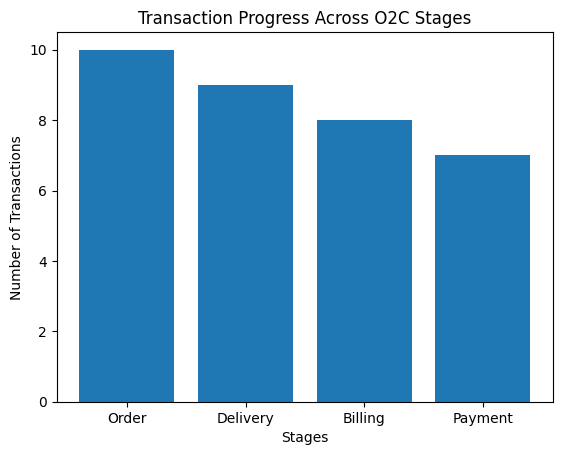

In [ ]:
import matplotlib.pyplot as plt

stages = ["Order", "Delivery", "Billing", "Payment"]
values = [10, 9, 8, 7]  # sample numbers

plt.bar(stages, values)
plt.title("Transaction Progress Across O2C Stages")
plt.xlabel("Stages")
plt.ylabel("Number of Transactions")
plt.show()